<a href="https://colab.research.google.com/github/Ahirvoas/Training-Day2/blob/main/Tutorial_day2-Anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wind Turbine Modeling Workshop

**How to use**
- Work through the notebook from top to bottom.
- Complete the `# TODO` parts. Hints are available inside `# Solution` sections (commented).
- Run cells incrementally and inspect intermediate outputs.


In [ ]:
!pip install gdown &> /dev/null
!gdown https://drive.google.com/uc?id=1h4pa6sSFbgaAi8zHObwtQIDVB8pBXoG-

Downloading...
From: https://drive.google.com/uc?id=1h4pa6sSFbgaAi8zHObwtQIDVB8pBXoG-
To: /content/dataset_anomalies.csv

  0% 0.00/92.7k [00:00<?, ?B/s]
100% 92.7k/92.7k [00:00<00:00, 77.1MB/s]


In [ ]:
!ls

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from imblearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

---

## Context and quick theory

Wind turbines are instrumented with multiple sensors (vibration, temperature, rotational speed, power, etc.).  
Anomalies in sensor readings may indicate faults, wear, or external events (e.g., icing, sudden gusts).  
Detecting anomalies early helps scheduling maintenance and preventing failures.

**Common approaches**:
- Simple statistical thresholds (mean ± k * std)  
- Time-series decomposition, rolling statistics  
- Machine learning models for anomaly detection (Isolation Forest, One-Class SVM, Autoencoders)

In this notebook, you will explore the dataset, preprocess signals, and run the anomaly detection pipeline.


## Part 1 — Data Loading & Exploration

**Goal:** Load the sensor dataset, examine time index, basic statistics, and plot example signals.

### Exercise
- Complete the `# EXERCISE` cell following this markdown to load the dataset and show basic stats.

In [ ]:
# EXERCISE: Load the dataset and show basic statistics (head, describe, time index check).
# TODO: Complete the code below


# Your code here

# ===== Example solution (commented) =====
# # Example solution:
# import pandas as pd
# df = pd.read_csv('path_to_file.csv')
# print(df.head())
# print(df.describe())
# ======================================


### Exercise
- Implement preprocessing (scaling).

In [ ]:
# EXERCISE: Implement a simple preprocessing function: fill missing values and scale using StandardScaler.
# TODO: Complete the code below


# Your code here

# ===== Example solution (commented) =====
# # Example solution:
# df_scaling = df.copy()
# scaler = StandardScaler()
# cols = [c for c in df_scaling.columns if c not in ['Fault']]
# df_scaling[cols] = scaler.fit_transform(df_scaling[cols])
# ======================================


In [ ]:
df['Fault'].unique()

array(['NF', 'MF', 'EF', 'AF'], dtype=object)

The fault dataset catalogs various fault types or modes that can occur in wind turbines. Specifically, it includes three types of faults:

* mf: Mains Failure Fault
* af: Timeout Warning Message - Malfunction Air Cooling
* ef: Excitation Error - Overvoltage DC-Link

This information is essential for diagnosing and understanding the different failure mechanisms that may affect turbine performance and reliability.

### Exercise
- Plot anomalies based on scatter plot.

In [ ]:
# EXERCISE: Plot anomalies based on scatter plot from tutorial in the tutorial from Day 1.
# TODO: Complete the code below


# Your code here


Stratified split to maintain anomaly ratio

In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Part 3 — Anomaly Detection

**Goal:** Use the anomaly detection algorithms present in the original notebook. Train the model(s) and obtain anomaly scores.

### Exercise
- Train the model(s) from notebook and compute anomaly scores.

In [7]:
# Make pipeline of scaling, and classifier
knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(weights='distance'))

In [9]:
# Define multiple scoring metrics
scoring = {'acc': 'accuracy',
           'rec_macro': 'recall_macro',
           'f1_macro': 'f1_macro'}

# Stratified K-Fold
stratkfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Return a dictionary of all scorings
cv_knn_scores = cross_validate(knn_pipe, X_train, y_train, cv=stratkfold, scoring=scoring)

In [12]:
# Fit pipeline to train set
knn_pipe.fit(X_train, y_train)

# Predict on test set
y_pred = knn_pipe.predict(X_test)

# Get the parameters of the model
params = knn_pipe.get_params()

# Print the parameters
print(params)

{'memory': None, 'steps': [('standardscaler', StandardScaler()), ('kneighborsclassifier', KNeighborsClassifier(weights='distance'))], 'transform_input': None, 'verbose': False, 'standardscaler': StandardScaler(), 'kneighborsclassifier': KNeighborsClassifier(weights='distance'), 'standardscaler__copy': True, 'standardscaler__with_mean': True, 'standardscaler__with_std': True, 'kneighborsclassifier__algorithm': 'auto', 'kneighborsclassifier__leaf_size': 30, 'kneighborsclassifier__metric': 'minkowski', 'kneighborsclassifier__metric_params': None, 'kneighborsclassifier__n_jobs': None, 'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__p': 2, 'kneighborsclassifier__weights': 'distance'}


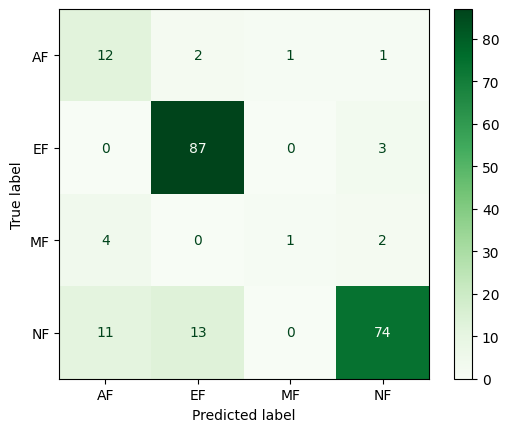

In [13]:
# Confusion matrix of test set
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Greens)
plt.show()

---

## Conclusion & Next Steps

- Discuss the limitations of the approach used in this notebook (false positives/negatives, concept drift, sensor faults that mimic anomalies).  
- Extensions for further work: time-series specific models (LSTM autoencoders), ensemble detection, data augmentation, root-cause analysis, explainability.

**Instructor note:** Solution hints were provided as commented blocks in exercise cells. Students should uncomment the Solution block only after attempting the exercise.



## Appendix — Understanding the Confusion Matrix

When evaluating an anomaly detection model, especially when ground truth labels are available, 
it is important to understand how well the model distinguishes **normal** versus **anomalous** cases.

The **confusion matrix** is a 2×2 table that compares predicted labels with actual labels:

|                     | Predicted Normal | Predicted Anomalous |
|---------------------:|:----------------:|:-------------------:|
| **Actual Normal**    | True Negative (TN) | False Positive (FP) |
| **Actual Anomalous** | False Negative (FN) | True Positive (TP) |

- **True Positive (TP)** — the model correctly detected an actual anomaly.  
- **False Positive (FP)** — the model flagged a normal sample as an anomaly (false alarm).  
- **True Negative (TN)** — the model correctly classified normal behavior.  
- **False Negative (FN)** — the model missed an anomaly (undetected fault).  

From this matrix, several performance metrics can be derived:

- **Precision** = TP / (TP + FP): among all detected anomalies, how many were correct?  
- **Recall** = TP / (TP + FN): among all real anomalies, how many were detected?  
- **F1-score** = 2 × (Precision × Recall) / (Precision + Recall): harmonic mean balancing both.

In anomaly detection, recall is often prioritized — we prefer to detect as many anomalies as possible, 
even at the cost of some false alarms. However, in industrial systems (like wind turbines), 
too many false positives can lead to unnecessary maintenance actions, so balance is key.
